# Overview: Wildfire Response Model

## Why - Understanding Drones in Wildfire response

![](drone-wildfire-pic.webp){height=275}

- Autonomous flight presents some major **long-term** opportunities for Wildfire Response, such as:

    - Flying with reduced risk to pilots
    - Increased aircraft availability for operations 
    - More information to ground operations
    - ...

- In-field evaluation is expensive
    - It's also limited to the types of assets we have now

- Need a testbed for **evaluating radical changes to ConOps** and **Missions enabled by autonomy**

PC: NASA/Daniel Rutter, nasa.gov/centers-and-facilities/ames/acero-and-wildland-fires


## What are we trying to do?

- Simulate firefighting response effectiveness of wildfire suppressions in a range of configurations, such as:
    - Types of aircraft
    - Coordination between aircraft
    - Types of bases and their placement



## Setup: Model Structure

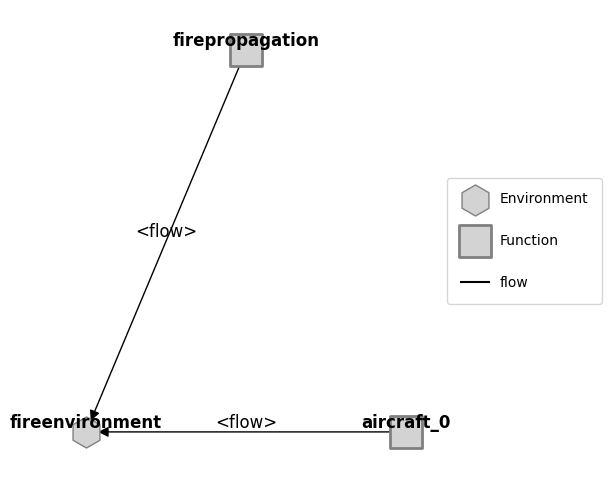

In [4]:
from fmdtools_examples.airspacelib.wildfire_response.model_main import WildfireSim
from fmdtools.define.architecture.function import FunctionArchitectureGraph
mdl_graph = FunctionArchitectureGraph(WildfireSim())
fig, ax = mdl_graph.draw(figsize=(5,6))

Major parts:

- FirePropagation: Determines spread of the fire over time based on environmental conditions (e.g., fuels)
- FireEnvironment: Shared grid of fuels, base placements, etc.
- Aircraft(s): Aircraft used for suppression efforts. **The number of aircraft may change depending on configuration**

Other parts could be added as needed e.g., for reconnaissance, lead planes, helicopters, etc.

## Setup: Environment and Mission

:::: {.columns}

::: {.column width="50%"}
![](outputs_demo_wildfire/single_aircraft_response.gif)
:::

::: {.column width="50%"}
![](outputs_demo_wildfire/single_aircraft_modes.gif)
:::
::::

- Fire propagates depending on environmental conditions--e.g., fuels etc.
- Aircraft perform different tasks:
    - Resupply (at base)
    - Flying to base
    - Flying to fire location
    - Fire mitigation (at fire)
- Fire location determined at base and refined in flight

## How effective are different numbers of aircraft?

![](outputs_demo_wildfire/multi_drone_response.gif)

- More effective (Fire out at t=25 min) due to more rapid response!
    - Fire is out before spreading out of control
- Assumption is one base per asset - can be improved in future work

## What if we move the location of the air base?

:::: {.columns}
::: {.column width="50%"}
![](outputs_paper_aiaa_optimal_location/init_burn_area.svg)
:::
::: {.column width="50%"}
![](outputs_paper_aiaa_optimal_location/opt_burn_area.svg)
:::
::::

- Study showed that response performs better when the base is closer to faster-burning fuels
- Down to 5% average area burned from 8% (see figures at right) over 50 3-strike fire scenarios.
- This optimization approach can be re-used to tailor the response to different maps 

See: [Hulse, D. E., Mbaye, S., & Davies, M. D. (2025). Determining Optimal Asset Location for Rapid and Efficient Wildfire Suppression: A Simulation-Based Approach. In AIAA SCITECH 2025 Forum (p. 0451).](https://ntrs.nasa.gov/api/citations/20240015828/downloads/Wildfire%20Simulation%20Optimization.pdf)


## What about alternative fire scenarios?

:::: {.columns}
::: {.column width="50%"}
![](outputs_demo_wildfire/three_strike_grass.gif)
:::
::: {.column width="50%"}
![](outputs_demo_wildfire/three_strike_forest.gif)
:::
::::

- Grass -> Fire more likely to spread uncontrollably
- Forest -> Fire mitigated quickly without spreading

These assumptions are simplistic!
- Real fires are much less predictable and firefighting is much less effective

## Conclusions and Path(s) from here {.smaller}

So far, we have developed a pretty basic multi-aircraft aerial firefighting model that answer questions about base allocation

**Potential extensions:**

- Add aircraft interactions in shared airspace
- Aerial reconnaissance and situation awareness effects studied previously by (Andrade & Hulse, 2022) in the Smart Stereo model
- Helicopters and ground-based fire mitigation
- Add in broad range of fire behaviors--wind, heat, etc.--to improve realism
- Ability to tailor to real historic fires
- Add in and study fault/failure scenarios


## Conclusions for fmdtools {.smaller}

This model showcases:

- The ability of fmdtools to model **Systems of Systems** where:
    - Multiple assets interacting with a shared environment
    - Many scenarios (strike locations, maps) for environment are possible
    - Environment also changes dynamically over time
- Parameterization--number of assets as well as properties of the environment can be changed
- The ability to efficiently optimize complex SoS models over a range of scenarios (in this case strike locations)